In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [ ]:
print(df3["Geography"].unique())

['Newfoundland and Labrador' nan 'Prince Edward Island' 'Nova Scotia'
 'New Brunswick' 'Quebec' 'Ontario' 'Manitoba' 'Saskatchewan' 'Alberta'
 'British Columbia' 'Yukon' 'Northwest Territories' 'Nunavut']


In [ ]:
df3["Geography"] = df3["Geography"].fillna(method="ffill")
df3["North American Industry Classification System (NAICS)"] = df3["North American Industry Classification System (NAICS)"].fillna(method="ffill")

df3.head()

C:\Users\mritt\AppData\Local\Temp\ipykernel_5736\3441986823.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df3["Geography"] = df3["Geography"].fillna(method="ffill")
C:\Users\mritt\AppData\Local\Temp\ipykernel_5736\3441986823.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df3["North American Industry Classification System (NAICS)"] = df3["North American Industry Classification System (NAICS)"].fillna(method="ffill")


,Geography,North American Industry Classification System (NAICS),REF-Date,GDP
0,Newfoundland and Labrador,All industries [T001] 5,2013,"30,873.00"
1,Newfoundland and Labrador,All industries [T001] 5,2014,"30,563.20"
2,Newfoundland and Labrador,All industries [T001] 5,2015,"30,194.20"
3,Newfoundland and Labrador,All industries [T001] 5,2016,"30,602.90"
4,Newfoundland and Labrador,All industries [T001] 5,2017,"31,002.70"


In [ ]:
print(df3["North American Industry Classification System (NAICS)"].unique())

['All industries  [T001] 5'
 'Agriculture, forestry, fishing and hunting  [11]'
 'Mining, quarrying, and oil and gas extraction  [21]' 'Utilities  [22]'
 'Construction  [23]' 'Manufacturing  [31-33]' 'Wholesale trade  [41]'
 'Retail trade  [44-45]' 'Transportation and warehousing  [48-49]'
 'Information and cultural industries  [51]' 'Finance and insurance  [52]'
 'Real estate and rental and leasing  [53]'
 'Professional, scientific and technical services  [54]'
 'Management of companies and enterprises  [55]'
 'Administrative and support, waste management and remediation services  [56]'
 'Educational services  [61]' 'Health care and social assistance  [62]'
 'Arts, entertainment and recreation  [71]'
 'Accommodation and food services  [72]'
 'Other services (except public administration)  [81]'
 'Public administration  [91]']


In [ ]:
df3["industry"] = df3["North American Industry Classification System (NAICS)"].str.extract("(\d+)")
df3["industry"] = df3["industry"].fillna(0).astype(int)
df3["industry"] = df3["industry"].astype(int)
df3.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\mritt\AppData\Local\Temp\ipykernel_5736\1163327427.py:1: SyntaxWarning: invalid escape sequence '\d'
  df3["industry"] = df3["North American Industry Classification System (NAICS)"].str.extract("(\d+)")


,Geography,North American Industry Classification System (NAICS),REF-Date,GDP,industry
0,Newfoundland and Labrador,All industries [T001] 5,2013,"30,873.00",1
1,Newfoundland and Labrador,All industries [T001] 5,2014,"30,563.20",1
2,Newfoundland and Labrador,All industries [T001] 5,2015,"30,194.20",1
3,Newfoundland and Labrador,All industries [T001] 5,2016,"30,602.90",1
4,Newfoundland and Labrador,All industries [T001] 5,2017,"31,002.70",1


In [ ]:
df3["industry"] = df3["industry"].replace(1, 0)

In [ ]:
print(df3["industry"].unique())

[ 0 11 21 22 23 31 41 44 48 51 52 53 54 55 56 61 62 71 72 81 91]


In [ ]:
df3 = df3.rename(columns={"Geography": "Province"})

In [ ]:
df3 = df3.drop(columns=["North American Industry Classification System (NAICS)"])

In [ ]:
df3["GDP"] = df3["GDP"].str.replace(",", "").astype(float).astype(int)

In [ ]:
print(df3["Province"].unique())

['Newfoundland and Labrador' 'Prince Edward Island' 'Nova Scotia'
 'New Brunswick' 'Quebec' 'Ontario' 'Manitoba' 'Saskatchewan' 'Alberta'
 'British Columbia' 'Yukon' 'Northwest Territories' 'Nunavut']


In [ ]:
print(df["GEO"].unique())

['Canada' 'Census metropolitan area (CMA)'
 "St. John's, Newfoundland and Labrador" 'Halifax, Nova Scotia'
 'Moncton, New Brunswick' 'Saint John, New Brunswick' 'Saguenay, Quebec'
 'Québec, Quebec' 'Sherbrooke, Quebec' 'Trois-Rivières, Quebec'
 'Montréal, Quebec' 'Ottawa-Gatineau, Ontario/Quebec' 'Kingston, Ontario'
 'Belleville - Quinte West, Ontario' 'Peterborough, Ontario'
 'Oshawa, Ontario' 'Toronto, Ontario' 'Hamilton, Ontario'
 'St. Catharines-Niagara, Ontario' 'Kitchener-Cambridge-Waterloo, Ontario'
 'Brantford, Ontario' 'Guelph, Ontario' 'London, Ontario'
 'Windsor, Ontario' 'Barrie, Ontario' 'Greater Sudbury, Ontario'
 'Thunder Bay, Ontario' 'Winnipeg, Manitoba' 'Regina, Saskatchewan'
 'Saskatoon, Saskatchewan' 'Lethbridge, Alberta' 'Calgary, Alberta'
 'Edmonton, Alberta' 'Kelowna, British Columbia'
 'Abbotsford-Mission, British Columbia' 'Vancouver, British Columbia'
 'Victoria, British Columbia' 'Non-Census metropolitan area'
 'Fredericton, New Brunswick' 'Drummondville, Que

In [ ]:
print(df2["GEO"].unique())

['Canada' 'Census metropolitan area (CMA)'
 "St. John's, Newfoundland and Labrador" 'Halifax, Nova Scotia'
 'Moncton, New Brunswick' 'Saint John, New Brunswick' 'Saguenay, Quebec'
 'Québec, Quebec' 'Sherbrooke, Quebec' 'Trois-Rivières, Quebec'
 'Montréal, Quebec' 'Ottawa-Gatineau, Ontario/Quebec' 'Kingston, Ontario'
 'Belleville - Quinte West, Ontario' 'Peterborough, Ontario'
 'Oshawa, Ontario' 'Toronto, Ontario' 'Hamilton, Ontario'
 'St. Catharines-Niagara, Ontario' 'Kitchener-Cambridge-Waterloo, Ontario'
 'Brantford, Ontario' 'Guelph, Ontario' 'London, Ontario'
 'Windsor, Ontario' 'Barrie, Ontario' 'Greater Sudbury, Ontario'
 'Thunder Bay, Ontario' 'Winnipeg, Manitoba' 'Regina, Saskatchewan'
 'Saskatoon, Saskatchewan' 'Lethbridge, Alberta' 'Calgary, Alberta'
 'Edmonton, Alberta' 'Kelowna, British Columbia'
 'Abbotsford-Mission, British Columbia' 'Vancouver, British Columbia'
 'Victoria, British Columbia' 'Non-Census metropolitan area'
 'Fredericton, New Brunswick' 'Drummondville, Que

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35632 entries, 0 to 35631
Data columns (total 16 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   REF_DATE                                               35632 non-null  int64  
 1   GEO                                                    35632 non-null  object 
 2   DGUID                                                  33532 non-null  object 
 3   Estimates                                              35632 non-null  object 
 4   North American Industry Classification System (NAICS)  35632 non-null  object 
 5   UOM                                                    35632 non-null  object 
 6   UOM_ID                                                 35632 non-null  int64  
 7   SCALAR_FACTOR                                          35632 non-null  object 
 8   SCALAR_ID                                     

In [ ]:
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30470 entries, 0 to 30469
Data columns (total 16 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   REF_DATE                                               30470 non-null  int64  
 1   GEO                                                    30470 non-null  object 
 2   DGUID                                                  28874 non-null  object 
 3   Estimates                                              30470 non-null  object 
 4   North American Industry Classification System (NAICS)  30470 non-null  object 
 5   UOM                                                    30470 non-null  object 
 6   UOM_ID                                                 30470 non-null  int64  
 7   SCALAR_FACTOR                                          30470 non-null  object 
 8   SCALAR_ID                                     

In [ ]:
df = df.drop('SYMBOL', axis=1)
df = df.drop("TERMINATED", axis=1)


In [ ]:
df2 = df2.drop('SYMBOL', axis=1)
df2 = df2.drop("TERMINATED", axis=1)

In [ ]:
df.isnull().sum()

REF_DATE                                                     0
GEO                                                          0
DGUID                                                     2100
Estimates                                                    0
North American Industry Classification System (NAICS)        0
UOM                                                          0
UOM_ID                                                       0
SCALAR_FACTOR                                                0
SCALAR_ID                                                    0
VECTOR                                                       0
COORDINATE                                                   0
VALUE                                                     7322
STATUS                                                   28310
DECIMALS                                                     0
dtype: int64

In [ ]:
df2.isnull().sum()

REF_DATE                                                     0
GEO                                                          0
DGUID                                                     1596
Estimates                                                    0
North American Industry Classification System (NAICS)        0
UOM                                                          0
UOM_ID                                                       0
SCALAR_FACTOR                                                0
SCALAR_ID                                                    0
VECTOR                                                       0
COORDINATE                                                   0
VALUE                                                     2655
STATUS                                                   27815
DECIMALS                                                     0
dtype: int64

In [ ]:
variation = df.nunique()
print(variation)


REF_DATE                                                    25
GEO                                                         44
DGUID                                                       42
Estimates                                                    2
North American Industry Classification System (NAICS)       21
UOM                                                          2
UOM_ID                                                       2
SCALAR_FACTOR                                                2
SCALAR_ID                                                    2
VECTOR                                                    1804
COORDINATE                                                1804
VALUE                                                    12281
STATUS                                                       3
DECIMALS                                                     1
dtype: int64


In [ ]:
variation = df2.nunique()
print(variation)

REF_DATE                                                    19
GEO                                                         44
DGUID                                                       42
Estimates                                                    2
North American Industry Classification System (NAICS)       21
UOM                                                          2
UOM_ID                                                       2
SCALAR_FACTOR                                                2
SCALAR_ID                                                    2
VECTOR                                                    1842
COORDINATE                                                1842
VALUE                                                    12514
STATUS                                                       3
DECIMALS                                                     1
dtype: int64


In [ ]:
print(df.columns)

Index(['REF_DATE', 'GEO', 'DGUID', 'Estimates',
       'North American Industry Classification System (NAICS)', 'UOM',
       'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE',
       'STATUS', 'DECIMALS'],
      dtype='object')


In [ ]:

df = df[["REF_DATE", "GEO", "Estimates", "North American Industry Classification System (NAICS)", "VALUE"]]
print(df)


       REF_DATE                           GEO  \
0          2000                        Canada   
1          2000                        Canada   
2          2000                        Canada   
3          2000                        Canada   
4          2000                        Canada   
...         ...                           ...   
35627      2024  Non-Census metropolitan area   
35628      2024  Non-Census metropolitan area   
35629      2024  Non-Census metropolitan area   
35630      2024  Non-Census metropolitan area   
35631      2024  Non-Census metropolitan area   

                                Estimates  \
0                        Value of exports   
1                        Value of exports   
2                        Value of exports   
3                        Value of exports   
4                        Value of exports   
...                                   ...   
35627  Number of exporting establishments   
35628  Number of exporting establishments   
35629 

In [ ]:
wide_export = df.pivot(index=["REF_DATE", "GEO", "North American Industry Classification System (NAICS)"], columns="Estimates", values="VALUE")
wide_export = wide_export.reset_index()

print(wide_export)


Estimates  REF_DATE                                   GEO  \
0              2000  Abbotsford-Mission, British Columbia   
1              2000  Abbotsford-Mission, British Columbia   
2              2000  Abbotsford-Mission, British Columbia   
3              2000  Abbotsford-Mission, British Columbia   
4              2000  Abbotsford-Mission, British Columbia   
...             ...                                   ...   
17811          2024                    Winnipeg, Manitoba   
17812          2024                    Winnipeg, Manitoba   
17813          2024                    Winnipeg, Manitoba   
17814          2024                    Winnipeg, Manitoba   
17815          2024                    Winnipeg, Manitoba   

Estimates North American Industry Classification System (NAICS)  \
0                       Accommodation and food services [72]      
1          Administrative and support, waste management a...      
2            Agriculture, forestry, fishing and hunting [11]      

In [ ]:
df2 = df2[["REF_DATE", "GEO", "Estimates", "North American Industry Classification System (NAICS)", "VALUE"]]
print(df2)

       REF_DATE                           GEO  \
0          2005                        Canada   
1          2005                        Canada   
2          2005                        Canada   
3          2005                        Canada   
4          2005                        Canada   
...         ...                           ...   
30465      2023  Non-Census metropolitan area   
30466      2023  Non-Census metropolitan area   
30467      2023  Non-Census metropolitan area   
30468      2023  Non-Census metropolitan area   
30469      2023  Non-Census metropolitan area   

                                Estimates  \
0                        Value of imports   
1                        Value of imports   
2                        Value of imports   
3                        Value of imports   
4                        Value of imports   
...                                   ...   
30465  Number of importing establishments   
30466  Number of importing establishments   
30467 

In [ ]:
wide_import = df2.pivot(index=["REF_DATE", "GEO", "North American Industry Classification System (NAICS)"], columns="Estimates", values="VALUE")
wide_import = wide_import.reset_index()

print(wide_import)

Estimates  REF_DATE                                   GEO  \
0              2005  Abbotsford-Mission, British Columbia   
1              2005  Abbotsford-Mission, British Columbia   
2              2005  Abbotsford-Mission, British Columbia   
3              2005  Abbotsford-Mission, British Columbia   
4              2005  Abbotsford-Mission, British Columbia   
...             ...                                   ...   
15230          2023                    Winnipeg, Manitoba   
15231          2023                    Winnipeg, Manitoba   
15232          2023                    Winnipeg, Manitoba   
15233          2023                    Winnipeg, Manitoba   
15234          2023                    Winnipeg, Manitoba   

Estimates North American Industry Classification System (NAICS)  \
0                       Accommodation and food services [72]      
1          Administrative and support, waste management a...      
2            Agriculture, forestry, fishing and hunting [11]      

In [ ]:
wide_export["industry"] = wide_export["North American Industry Classification System (NAICS)"].str.extract("(\d+)")
wide_export["industry"] = wide_export["industry"].fillna(0).astype(int)
wide_export["industry"] = wide_export["industry"].astype(int)
wide_export.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\mritt\AppData\Local\Temp\ipykernel_5736\3745283925.py:1: SyntaxWarning: invalid escape sequence '\d'
  wide_export["industry"] = wide_export["North American Industry Classification System (NAICS)"].str.extract("(\d+)")


Estimates,REF_DATE,GEO,North American Industry Classification System (NAICS),Number of exporting establishments,Value of exports,industry
0,2000,"Abbotsford-Mission, British Columbia",Accommodation and food services [72],NaN,NaN,72
1,2000,"Abbotsford-Mission, British Columbia","Administrative and support, waste management a...",NaN,NaN,56
2,2000,"Abbotsford-Mission, British Columbia","Agriculture, forestry, fishing and hunting [11]",NaN,NaN,11
3,2000,"Abbotsford-Mission, British Columbia",All industries,NaN,NaN,0
4,2000,"Abbotsford-Mission, British Columbia","Arts, entertainment and recreation [71]",NaN,NaN,71


In [ ]:
wide_import["industry"] = wide_import["North American Industry Classification System (NAICS)"].str.extract("(\d+)")
wide_import["industry"] = wide_import["industry"].fillna(0).astype(int)
wide_import["industry"] = wide_import["industry"].astype(int)
wide_import.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\mritt\AppData\Local\Temp\ipykernel_5736\1669764391.py:1: SyntaxWarning: invalid escape sequence '\d'
  wide_import["industry"] = wide_import["North American Industry Classification System (NAICS)"].str.extract("(\d+)")


Estimates,REF_DATE,GEO,North American Industry Classification System (NAICS),Number of importing establishments,Value of imports,industry
0,2005,"Abbotsford-Mission, British Columbia",Accommodation and food services [72],19.0,59.0,72
1,2005,"Abbotsford-Mission, British Columbia","Administrative and support, waste management a...",19.0,2399.0,56
2,2005,"Abbotsford-Mission, British Columbia","Agriculture, forestry, fishing and hunting [11]",138.0,36147.0,11
3,2005,"Abbotsford-Mission, British Columbia",All industries,901.0,691174.0,0
4,2005,"Abbotsford-Mission, British Columbia","Arts, entertainment and recreation [71]",5.0,56.0,71


In [ ]:
print(wide_export["industry"].unique())

[72 56 11  0 71 23 52 62 51 31 21 81 54 53 44 48 22 41 61 91 55]


In [ ]:
wide_export = wide_export[(wide_export['REF_DATE'] >= 2013) & (wide_export['REF_DATE'] <= 2023)]
wide_export.head()

Estimates,REF_DATE,GEO,North American Industry Classification System (NAICS),Number of exporting establishments,Value of exports,industry
9016,2013,"Abbotsford-Mission, British Columbia","Administrative and support, waste management a...",NaN,7643.0,56
9017,2013,"Abbotsford-Mission, British Columbia","Agriculture, forestry, fishing and hunting [11]",32.0,71539.0,11
9018,2013,"Abbotsford-Mission, British Columbia",All industries,303.0,597215.0,0
9019,2013,"Abbotsford-Mission, British Columbia","Arts, entertainment and recreation [71]",NaN,3.0,71
9020,2013,"Abbotsford-Mission, British Columbia",Construction [23],17.0,4381.0,23


In [ ]:
wide_import = wide_import[(wide_import['REF_DATE'] >= 2013) & (wide_import['REF_DATE'] <= 2023)]
wide_import.head()

Estimates,REF_DATE,GEO,North American Industry Classification System (NAICS),Number of importing establishments,Value of imports,industry
6258,2013,"Abbotsford-Mission, British Columbia",Accommodation and food services [72],16.0,70.0,72
6259,2013,"Abbotsford-Mission, British Columbia","Administrative and support, waste management a...",31.0,2394.0,56
6260,2013,"Abbotsford-Mission, British Columbia","Agriculture, forestry, fishing and hunting [11]",172.0,41396.0,11
6261,2013,"Abbotsford-Mission, British Columbia",All industries,1040.0,581814.0,0
6262,2013,"Abbotsford-Mission, British Columbia","Arts, entertainment and recreation [71]",8.0,193.0,71


In [ ]:
wide_export = wide_export.dropna(subset=["Value of exports"])
wide_import = wide_import.dropna(subset=["Value of imports"])

In [ ]:
merged = pd.merge(wide_export, wide_import, on=["GEO", "REF_DATE", "industry"], how="inner")
merged.head()

Estimates,REF_DATE,GEO,North American Industry Classification System (NAICS)_x,Number of exporting establishments,Value of exports,industry,North American Industry Classification System (NAICS)_y,Number of importing establishments,Value of imports
0,2013,"Abbotsford-Mission, British Columbia","Administrative and support, waste management a...",NaN,7643.0,56,"Administrative and support, waste management a...",31.0,2394.0
1,2013,"Abbotsford-Mission, British Columbia","Agriculture, forestry, fishing and hunting [11]",32.0,71539.0,11,"Agriculture, forestry, fishing and hunting [11]",172.0,41396.0
2,2013,"Abbotsford-Mission, British Columbia",All industries,303.0,597215.0,0,All industries,1040.0,581814.0
3,2013,"Abbotsford-Mission, British Columbia","Arts, entertainment and recreation [71]",NaN,3.0,71,"Arts, entertainment and recreation [71]",8.0,193.0
4,2013,"Abbotsford-Mission, British Columbia",Construction [23],17.0,4381.0,23,Construction [23],86.0,43788.0


In [ ]:
merged[["CMA", "Province"]] = merged["GEO"].str.split(",", expand=True)
merged.head()

Estimates,REF_DATE,GEO,North American Industry Classification System (NAICS)_x,Number of exporting establishments,Value of exports,industry,North American Industry Classification System (NAICS)_y,Number of importing establishments,Value of imports,CMA,Province
0,2013,"Abbotsford-Mission, British Columbia","Administrative and support, waste management a...",NaN,7643.0,56,"Administrative and support, waste management a...",31.0,2394.0,Abbotsford-Mission,British Columbia
1,2013,"Abbotsford-Mission, British Columbia","Agriculture, forestry, fishing and hunting [11]",32.0,71539.0,11,"Agriculture, forestry, fishing and hunting [11]",172.0,41396.0,Abbotsford-Mission,British Columbia
2,2013,"Abbotsford-Mission, British Columbia",All industries,303.0,597215.0,0,All industries,1040.0,581814.0,Abbotsford-Mission,British Columbia
3,2013,"Abbotsford-Mission, British Columbia","Arts, entertainment and recreation [71]",NaN,3.0,71,"Arts, entertainment and recreation [71]",8.0,193.0,Abbotsford-Mission,British Columbia
4,2013,"Abbotsford-Mission, British Columbia",Construction [23],17.0,4381.0,23,Construction [23],86.0,43788.0,Abbotsford-Mission,British Columbia


In [ ]:
merged["CMA"] = merged["CMA"].replace("Canada", None)
merged["CMA"] = merged["CMA"].replace("Census metropolitan area (CMA)", None)
merged["CMA"] = merged["CMA"].replace("Non-Census metropolitan area", None)
merged.head()

Estimates,REF_DATE,GEO,North American Industry Classification System (NAICS)_x,Number of exporting establishments,Value of exports,industry,North American Industry Classification System (NAICS)_y,Number of importing establishments,Value of imports,CMA,Province
0,2013,"Abbotsford-Mission, British Columbia","Administrative and support, waste management a...",NaN,7643.0,56,"Administrative and support, waste management a...",31.0,2394.0,Abbotsford-Mission,British Columbia
1,2013,"Abbotsford-Mission, British Columbia","Agriculture, forestry, fishing and hunting [11]",32.0,71539.0,11,"Agriculture, forestry, fishing and hunting [11]",172.0,41396.0,Abbotsford-Mission,British Columbia
2,2013,"Abbotsford-Mission, British Columbia",All industries,303.0,597215.0,0,All industries,1040.0,581814.0,Abbotsford-Mission,British Columbia
3,2013,"Abbotsford-Mission, British Columbia","Arts, entertainment and recreation [71]",NaN,3.0,71,"Arts, entertainment and recreation [71]",8.0,193.0,Abbotsford-Mission,British Columbia
4,2013,"Abbotsford-Mission, British Columbia",Construction [23],17.0,4381.0,23,Construction [23],86.0,43788.0,Abbotsford-Mission,British Columbia


In [ ]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7854 entries, 0 to 7853
Data columns (total 11 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   REF_DATE                                                 7854 non-null   int64  
 1   GEO                                                      7854 non-null   object 
 2   North American Industry Classification System (NAICS)_x  7854 non-null   object 
 3   Number of exporting establishments                       5358 non-null   float64
 4   Value of exports                                         7854 non-null   float64
 5   industry                                                 7854 non-null   int32  
 6   North American Industry Classification System (NAICS)_y  7854 non-null   object 
 7   Number of importing establishments                       7360 non-null   float64
 8   Value of imports            

In [ ]:
merged['total_trade'] = merged['Value of exports'] + merged['Value of imports']
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7854 entries, 0 to 7853
Data columns (total 12 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   REF_DATE                                                 7854 non-null   int64  
 1   GEO                                                      7854 non-null   object 
 2   North American Industry Classification System (NAICS)_x  7854 non-null   object 
 3   Number of exporting establishments                       5358 non-null   float64
 4   Value of exports                                         7854 non-null   float64
 5   industry                                                 7854 non-null   int32  
 6   North American Industry Classification System (NAICS)_y  7854 non-null   object 
 7   Number of importing establishments                       7360 non-null   float64
 8   Value of imports            

In [ ]:
merged = merged.drop(merged[merged["GEO"] == "Canada"].index)
merged = merged.drop(merged[merged["GEO"] == "None"].index)

merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7623 entries, 0 to 7853
Data columns (total 12 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   REF_DATE                                                 7623 non-null   int64  
 1   GEO                                                      7623 non-null   object 
 2   North American Industry Classification System (NAICS)_x  7623 non-null   object 
 3   Number of exporting establishments                       5127 non-null   float64
 4   Value of exports                                         7623 non-null   float64
 5   industry                                                 7623 non-null   int32  
 6   North American Industry Classification System (NAICS)_y  7623 non-null   object 
 7   Number of importing establishments                       7129 non-null   float64
 8   Value of imports                 

In [ ]:
merged = merged[merged["Province"].notna()]


In [ ]:
print(merged["Province"].unique())

[' British Columbia' ' Ontario' ' Alberta' ' Nova Scotia' ' New Brunswick'
 ' Quebec' ' Ontario/Quebec' ' Saskatchewan' ' Newfoundland and Labrador'
 ' Manitoba']


In [ ]:
print(df3["Province"].unique())

['Newfoundland and Labrador' 'Prince Edward Island' 'Nova Scotia'
 'New Brunswick' 'Quebec' 'Ontario' 'Manitoba' 'Saskatchewan' 'Alberta'
 'British Columbia' 'Yukon' 'Northwest Territories' 'Nunavut']


In [ ]:
merged["Province"] = merged["Province"].replace(' British Columbia', 'British Columbia')
merged["Province"] = merged["Province"].replace(' Ontario', 'Ontario')
merged["Province"] = merged["Province"].replace(' Alberta', 'Alberta')
merged["Province"] = merged["Province"].replace(' Nova Scotia', 'Nova Scotia')
merged["Province"] = merged["Province"].replace(' New Brunswick', 'New Brunswick')
merged["Province"] = merged["Province"].replace(' Quebec', 'Quebec')
merged["Province"] = merged["Province"].replace(' Saskatchewan', 'Saskatchewan')
merged["Province"] = merged["Province"].replace( ' Newfoundland and Labrador', 'Newfoundland and Labrador')
merged["Province"] = merged["Province"].replace( ' Manitoba', 'Manitoba')
merged["Province"] = merged["Province"].replace( ' Ontario/Quebec', 'Ontario')





In [ ]:
df3 = df3.rename(columns={"REF-Date": "REF_DATE"})

In [ ]:
merged = merged.drop('North American Industry Classification System (NAICS)_x', axis=1)
merged = merged.drop('North American Industry Classification System (NAICS)_y', axis=1)

In [ ]:
merged = (
    merged.groupby(["Province", "industry", "REF_DATE"])["total_trade"]
    .sum()        # or .mean(), depending on what you want
    .reset_index()
)


In [ ]:
trade = pd.merge(merged, df3, on=["Province", "REF_DATE", "industry"], how="left")
trade.head()

,Province,industry,REF_DATE,total_trade,GDP
0,Alberta,0,2013,139364164.0,310713
1,Alberta,0,2014,153658120.0,328652
2,Alberta,0,2015,120889390.0,317182
3,Alberta,0,2016,104104281.0,306203
4,Alberta,0,2017,125464737.0,319212


In [ ]:
trade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2029 entries, 0 to 2028
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Province     2029 non-null   object 
 1   industry     2029 non-null   int32  
 2   REF_DATE     2029 non-null   int64  
 3   total_trade  2029 non-null   float64
 4   GDP          2029 non-null   int32  
dtypes: float64(1), int32(2), int64(1), object(1)
memory usage: 63.5+ KB


In [ ]:
trade["trade_pct_gdp"] = (trade["total_trade"] / trade["GDP"]) *(1/10)

In [ ]:
df.to_csv("trade.csv", index=False)

In [ ]:
trade["trade_pct_gdp"].describe()


count    2029.000000
mean       29.313282
std        71.921032
min         0.001176
25%         0.893499
50%         4.407647
75%        21.349252
max       838.938106
Name: trade_pct_gdp, dtype: float64

In [ ]:
trade.head()

,Province,industry,REF_DATE,total_trade,GDP,trade_pct_gdp
0,Alberta,0,2013,139364164.0,310713,44.853020
1,Alberta,0,2014,153658120.0,328652,46.754050
2,Alberta,0,2015,120889390.0,317182,38.113572
3,Alberta,0,2016,104104281.0,306203,33.998452
4,Alberta,0,2017,125464737.0,319212,39.304518


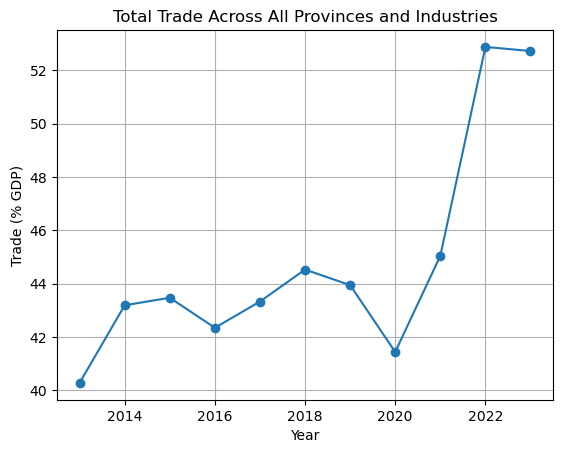

In [ ]:
agg_df = trade.groupby("REF_DATE")[["total_trade", "GDP"]].sum().reset_index()
agg_df["trade_p"] = (agg_df["total_trade"] / agg_df["GDP"]) * (1/10)
# Plot single time series
plt.plot(agg_df["REF_DATE"], agg_df["trade_p"], marker="o")
plt.title("Total Trade Across All Provinces and Industries")
plt.xlabel("Year")
plt.ylabel("Trade (% GDP)")
plt.grid(True)
plt.show()


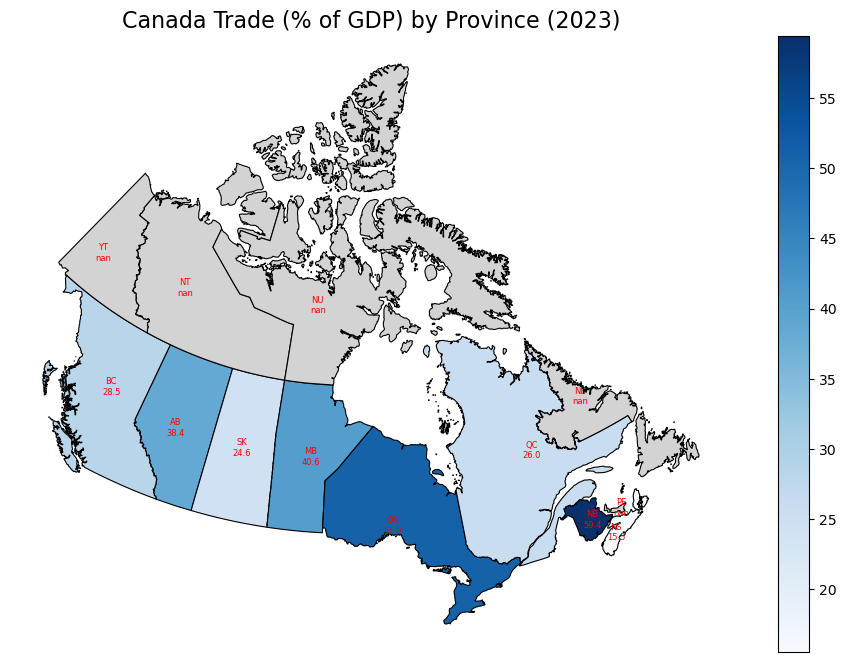

In [ ]:
from adjustText import adjust_text

# --- Step 1: Load map ---
canada_map = gpd.read_file("canada_provinces.geojson")

# --- Step 2: Aggregate trade data ---
trade_2023 = (
    trade[trade["REF_DATE"] == 2023]
    .groupby("Province")["trade_pct_gdp"]
    .mean()
    .reset_index()
)

# --- Step 3: Merge with map ---
canada_map = canada_map.merge(trade_2023, left_on="NAME", right_on="Province", how="left")

# --- Step 4: Reproject to equal-area CRS (Canada Albers Equal Area) ---
canada_map_proj = canada_map.to_crs(epsg=3347)

# --- Step 5: Province abbreviation dictionary ---
province_abbrev = {
    "Alberta": "AB", "British Columbia": "BC", "Manitoba": "MB",
    "New Brunswick": "NB", "Newfoundland  & Labrador": "NL", "Nova Scotia": "NS",
    "Ontario": "ON", "Prince Edward Island": "PE", "Quebec": "QC", "Saskatchewan": "SK",
    "Northwest Territories": "NT", "Nunavut": "NU", "Yukon Territory": "YT"
}

# --- Step 6: Plot map ---
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
canada_map_proj.plot(
    column="trade_pct_gdp",
    cmap="Blues",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Missing data"}
)

for idx, row in canada_map_proj.iterrows():
    if row["trade_pct_gdp"] is not None:
        abbrev = province_abbrev.get(row["NAME"], row["NAME"])

        # Use representative_point() so the label is guaranteed to be inside the polygon
        point = row.geometry.representative_point()

        # Abbreviation on top, value underneath
        label_text = f"{abbrev}\n{row['trade_pct_gdp']:.1f}"

        ax.annotate(
            text=label_text,
            xy=(point.x, point.y),
            ha="center",
            va="center",   # vertical alignment ensures text is centered
            fontsize=6,
            color="red"
        )


plt.title("Canada Trade (% of GDP) by Province (2023)", fontsize=16)
plt.axis("off")
plt.show()